# Summary: 2a_Data_Repair

This notebook repairs known zero-sales (repair) periods for selected product families and builds total and weekly sales series for forecasting.

**Structure:**
- **Data loading:** Import train.csv and Repair_Periods (CSV or Excel); define repair families and date ranges.
- **Repair-period overview:** Print date ranges by product family; set sales to zero for (family, date) in each repair period; plot sales (with zeros) for those families only.
- **Prophet-based repair:** For each repair family, fit Prophet on daily sales (excluding repair-period dates) and predict for repair-period dates; build repaired daily series per family; plot repaired daily sales.
- **Total and weekly sales:** Total daily sales from 2014 (repaired for repair families, original for others); weekly total sales; rolling 30-day mean ± 1 std.
- **Forecasts:** Daily (30-day) and weekly (4-week) forecasts using ETS, ARIMA, and Prophet (80% train / 20% test, exclude 2013); report MAE, RMSE, MAPE; plot train actual, test actual, and forecasts (full and zoomed panels).
- **Proof:** Show that total daily sales sum over all product families (repaired where applicable).

**Key outputs:** repaired_df (repaired daily sales by family), total_repaired (total daily; January 1 of each year excluded for train/test and all subsequent forecasting), Total_Repaired_Daily.csv, and forecast metrics and plots.

In [129]:
# Load train and Repair_Periods; parse dates; display shapes and first rows.
# Import data from train.csv and Repair_Periods (CSV or Excel)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = "data"  # folder relative to notebook; or use full path
train = pd.read_csv(f"{DATA}/train.csv", parse_dates=["date"])

# Repair_Periods: try CSV first, then Excel
try:
    repair_periods = pd.read_csv(f"{DATA}/Repair_Periods.csv")
except FileNotFoundError:
    repair_periods = pd.read_excel(f"{DATA}/Repair_Periods.xlsx", engine="openpyxl")
repair_periods["Start date"] = pd.to_datetime(repair_periods["Start date"])
repair_periods["End date"] = pd.to_datetime(repair_periods["End date"])

print("Train shape:", train.shape)
print("Repair periods shape:", repair_periods.shape)
repair_periods.head(10)


Train shape: (3000888, 6)
Repair periods shape: (38, 3)


,Family,Start date,End date
0,BEVERAGES,2014-02-01,2014-02-28
1,BEVERAGES,2014-04-01,2014-06-30
2,BEVERAGES,2014-08-01,2014-08-31
3,BEVERAGES,2015-01-01,2015-05-03
4,BEVERAGES,2015-01-01,2015-05-24
5,BEVERAGES,2015-01-01,2015-05-31
6,PRODUCE,2013-01-01,2013-03-15
7,PRODUCE,2014-02-01,2014-02-28
8,PRODUCE,2014-04-01,2014-06-30
9,PRODUCE,2014-08-01,2014-08-31


In [130]:
# Print date ranges by product family for all repair periods.
# Observe date ranges by product family
print("Date ranges by product family (repair periods):\n")
for fam in repair_periods["Family"].unique():
    subset = repair_periods[repair_periods["Family"] == fam]
    print(f"{fam}:")
    for _, row in subset.iterrows():
        print(f"  {row['Start date'].date()} to {row['End date'].date()}")
    print()
repair_periods


Date ranges by product family (repair periods):

BEVERAGES:
  2014-02-01 to 2014-02-28
  2014-04-01 to 2014-06-30
  2014-08-01 to 2014-08-31
  2015-01-01 to 2015-05-03
  2015-01-01 to 2015-05-24
  2015-01-01 to 2015-05-31

PRODUCE:
  2013-01-01 to 2013-03-15
  2014-02-01 to 2014-02-28
  2014-04-01 to 2014-06-30
  2014-08-01 to 2014-08-31
  2015-01-01 to 2015-05-03
  2015-01-01 to 2015-05-24
  2015-01-01 to 2015-05-31

HOME CARE:
  2013-01-01 to 2013-12-31
  2014-02-01 to 2014-02-28
  2014-04-01 to 2014-06-30
  2014-08-01 to 2014-08-31
  2015-01-01 to 2015-05-03

CELEBRATION:
  2013-01-01 to 2013-12-31
  2014-02-01 to 2014-02-28
  2014-04-01 to 2014-06-30
  2014-08-01 to 2014-08-31
  2015-01-01 to 2015-05-31

PET SUPPLIES:
  2013-01-01 to 2013-12-31
  2014-02-01 to 2014-02-28
  2014-04-01 to 2014-06-30
  2014-08-01 to 2014-08-31
  2015-01-01 to 2015-05-24

PLAYERS AND ELECTRONICS:
  2013-01-01 to 2013-12-31
  2014-02-01 to 2014-02-28
  2014-04-01 to 2014-06-30
  2014-08-01 to 2014-08-31

,Family,Start date,End date
0,BEVERAGES,2014-02-01,2014-02-28
1,BEVERAGES,2014-04-01,2014-06-30
2,BEVERAGES,2014-08-01,2014-08-31
3,BEVERAGES,2015-01-01,2015-05-03
4,BEVERAGES,2015-01-01,2015-05-24
5,BEVERAGES,2015-01-01,2015-05-31
6,PRODUCE,2013-01-01,2013-03-15
7,PRODUCE,2014-02-01,2014-02-28
8,PRODUCE,2014-04-01,2014-06-30
9,PRODUCE,2014-08-01,2014-08-31


In [131]:
# Set sales to zero for (family, date) in each repair period; build train_zeros.
# Replace sales with zeros for (family, date) in each repair period
train_zeros = train.copy()
for _, row in repair_periods.iterrows():
    fam = row["Family"]
    start = row["Start date"]
    end = row["End date"]
    mask = (
        (train_zeros["family"] == fam)
        & (train_zeros["date"] >= start)
        & (train_zeros["date"] <= end)
    )
    train_zeros.loc[mask, "sales"] = 0

families_in_repair = repair_periods["Family"].unique().tolist()
train_families = train_zeros[train_zeros["family"].isin(families_in_repair)]
daily_by_family = train_families.groupby(["date", "family"])["sales"].sum().unstack(fill_value=0)
daily_by_family = daily_by_family.reindex(columns=[f for f in families_in_repair if f in daily_by_family.columns])
print("Daily sales (zeros applied) for families in Repair_Periods:")
daily_by_family.head(10)


Daily sales (zeros applied) for families in Repair_Periods:


family,BEVERAGES,PRODUCE,HOME CARE,CELEBRATION,PET SUPPLIES,PLAYERS AND ELECTRONICS,LADIESWEAR
date,,,,,,,
2013-01-01,810.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-02,72092.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-03,52105.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-04,54167.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-05,77818.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-06,86184.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-07,51619.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-08,46941.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-09,47910.0,0.0,0.0,0.0,0.0,0.0,0.0


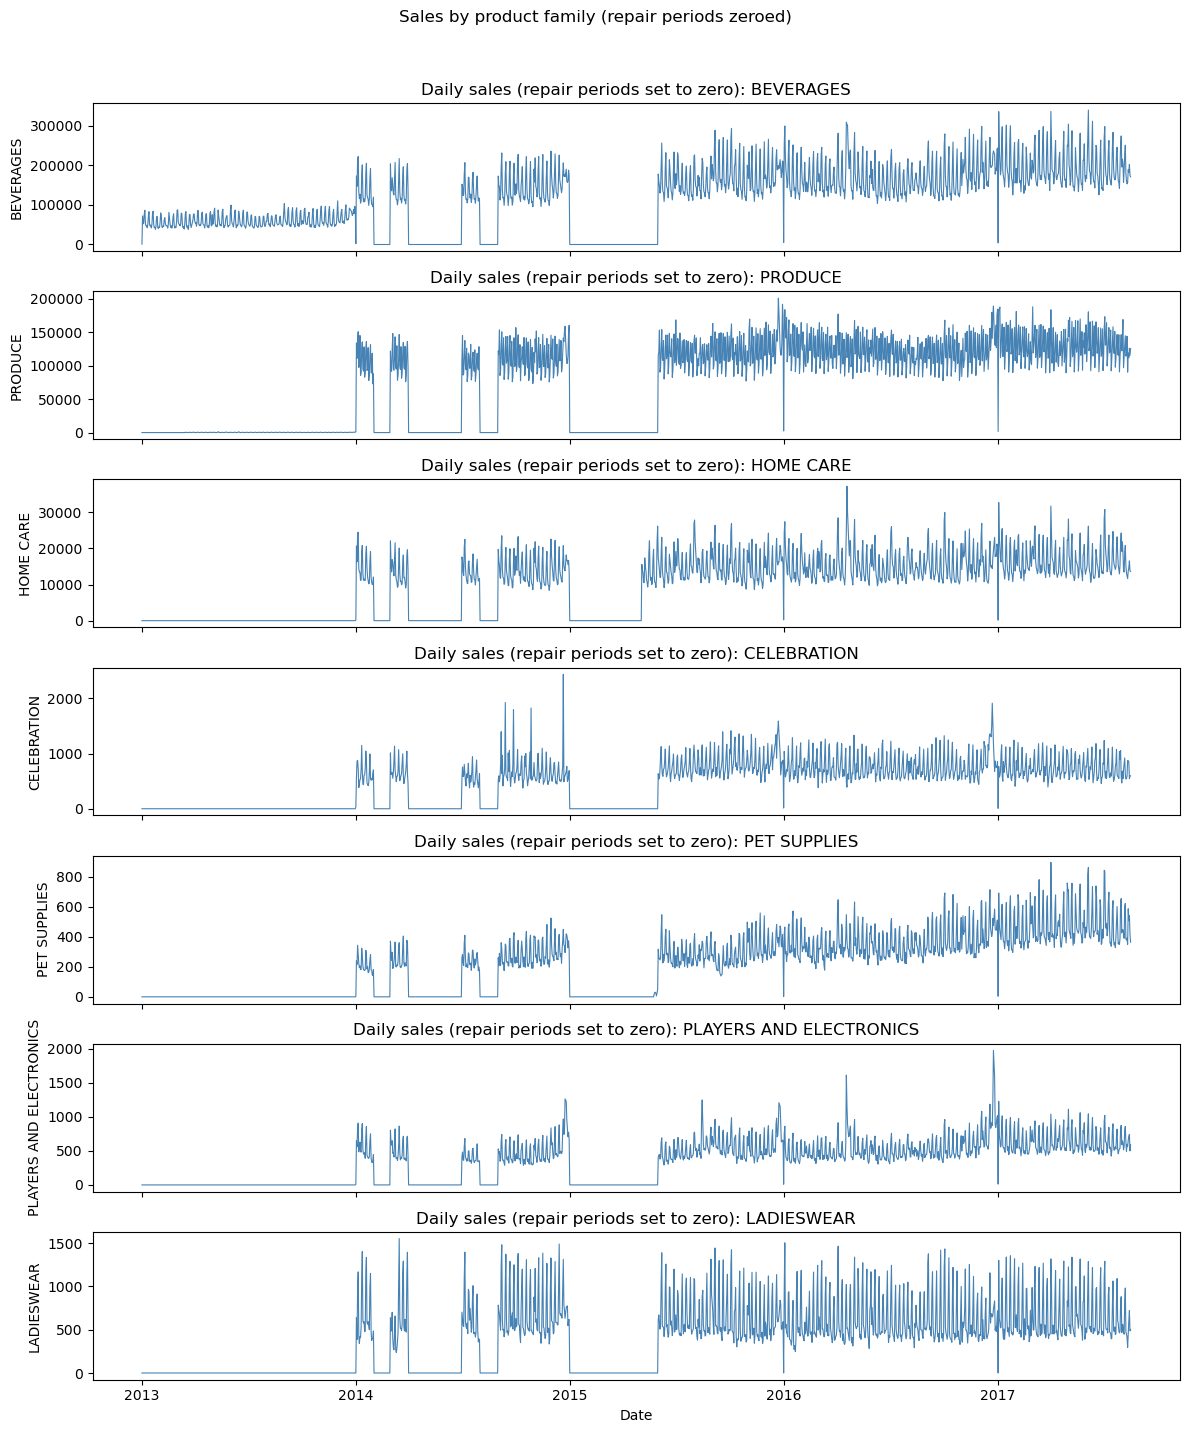

In [132]:
# Plot daily sales (zeros in repair periods) for repair families only.
# Plot sales (with zeros in repair periods) for those product families only
n_families = len(families_in_repair)
fig, axes = plt.subplots(n_families, 1, figsize=(12, 2 * n_families), sharex=True)
if n_families == 1:
    axes = [axes]
for i, col in enumerate(daily_by_family.columns):
    axes[i].plot(daily_by_family.index, daily_by_family[col].values, color="steelblue", linewidth=0.8)
    axes[i].set_ylabel(col)
    axes[i].set_title(f"Daily sales (repair periods set to zero): {col}")
axes[-1].set_xlabel("Date")
plt.suptitle("Sales by product family (repair periods zeroed)", y=1.02)
plt.tight_layout()
plt.show()


In [133]:
# Fit Prophet per repair family to fill repair-period dates; build repaired_df.
# Fit Prophet to fill repair periods using all sales data (original train)
# For each repair family: fit on daily sales from original train (excluding repair-period dates), predict for repair-period dates
# Requires: pip install prophet
from prophet import Prophet

daily_all = train.groupby(["date", "family"])["sales"].sum().unstack(fill_value=0)
date_range = daily_all.index

repaired_daily = {}
for fam in families_in_repair:
    if fam not in daily_all.columns:
        continue
    ser = daily_all[fam].copy()
    periods_fam = repair_periods[repair_periods["Family"] == fam]
    if len(periods_fam) == 0:
        repaired_daily[fam] = ser
        continue
    # Build fit dataframe: exclude repair-period dates so Prophet doesn't learn zeros
    fit_df = ser.reset_index()
    fit_df.columns = ["ds", "y"]
    for _, row in periods_fam.iterrows():
        start, end = row["Start date"], row["End date"]
        fit_df.loc[(fit_df["ds"] >= start) & (fit_df["ds"] <= end), "y"] = np.nan
    fit_df = fit_df.dropna(subset=["y"])
    if len(fit_df) < 2:
        repaired_daily[fam] = ser
        continue
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.fit(fit_df)
    # Predict for all dates in repair periods for this family
    repair_dates = []
    for _, row in periods_fam.iterrows():
        repair_dates.extend(pd.date_range(row["Start date"], row["End date"], freq="D").tolist())
    repair_dates = pd.Series(repair_dates).drop_duplicates().sort_values()
    if len(repair_dates) == 0:
        repaired_daily[fam] = ser
        continue
    future = pd.DataFrame({"ds": repair_dates})
    forecast = model.predict(future)
    repaired_ser = ser.copy()
    for d, yhat in zip(forecast["ds"], forecast["yhat"]):
        d = pd.Timestamp(d).normalize()
        if d in repaired_ser.index:
            repaired_ser.loc[d] = max(0.0, yhat)
    repaired_daily[fam] = repaired_ser

repaired_df = pd.DataFrame(repaired_daily).reindex(date_range).fillna(0)
repaired_df = repaired_df.reindex(columns=[f for f in families_in_repair if f in repaired_df.columns])
print("Repaired daily sales (Prophet-filled repair periods):")
repaired_df.head(10)

17:49:02 - cmdstanpy - INFO - Chain [1] start processing
17:49:02 - cmdstanpy - INFO - Chain [1] done processing
17:49:03 - cmdstanpy - INFO - Chain [1] start processing
17:49:03 - cmdstanpy - INFO - Chain [1] done processing
17:49:03 - cmdstanpy - INFO - Chain [1] start processing
17:49:03 - cmdstanpy - INFO - Chain [1] done processing
17:49:03 - cmdstanpy - INFO - Chain [1] start processing
17:49:04 - cmdstanpy - INFO - Chain [1] done processing
17:49:04 - cmdstanpy - INFO - Chain [1] start processing
17:49:04 - cmdstanpy - INFO - Chain [1] done processing
17:49:04 - cmdstanpy - INFO - Chain [1] start processing
17:49:05 - cmdstanpy - INFO - Chain [1] done processing
17:49:05 - cmdstanpy - INFO - Chain [1] start processing
17:49:05 - cmdstanpy - INFO - Chain [1] done processing


Repaired daily sales (Prophet-filled repair periods):


,BEVERAGES,PRODUCE,HOME CARE,CELEBRATION,PET SUPPLIES,PLAYERS AND ELECTRONICS,LADIESWEAR
date,,,,,,,
2013-01-01,810.0,0.000000,13467.290411,534.209416,117.816765,668.983868,550.996743
2013-01-02,72092.0,10432.574925,12947.046260,567.051655,126.009990,654.137895,536.515300
2013-01-03,52105.0,0.000000,11339.748603,615.075946,99.522907,594.919735,475.589487
2013-01-04,54167.0,0.000000,12032.901169,756.945903,119.163221,615.399850,499.968237
2013-01-05,77818.0,2405.900005,18428.222246,966.236349,271.386748,820.067525,931.506053
2013-01-06,86184.0,12606.782035,20399.392147,546.624065,296.459531,865.025097,1143.622216
2013-01-07,51619.0,0.000000,14325.079894,404.965638,132.482116,580.180281,560.137591
2013-01-08,46941.0,0.000000,12728.909331,427.451296,104.599739,525.695623,521.144726
2013-01-09,47910.0,18963.809519,12128.548476,471.788859,113.883701,511.817623,511.089352


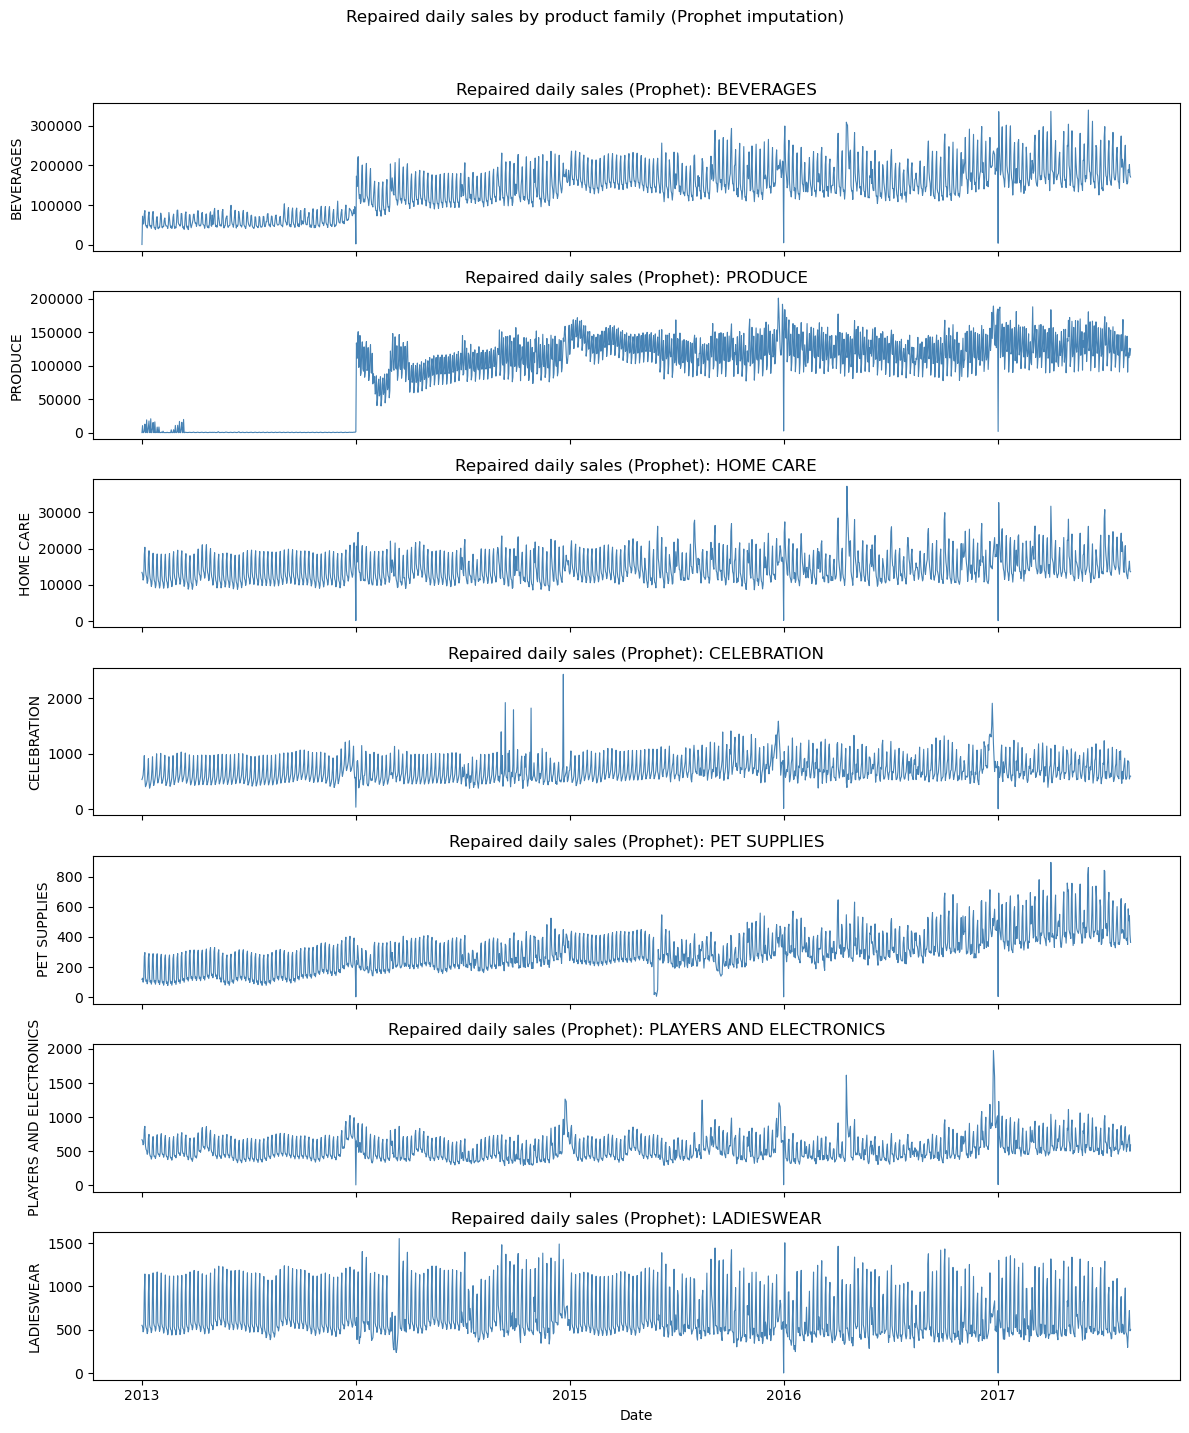

In [134]:
# Plot repaired daily sales for each repair family (Prophet-filled).
# Plot repaired daily sales for the product families (Prophet-filled repair periods)
n_families = len(repaired_df.columns)
fig, axes = plt.subplots(n_families, 1, figsize=(12, 2 * n_families), sharex=True)
if n_families == 1:
    axes = [axes]
for i, col in enumerate(repaired_df.columns):
    axes[i].plot(repaired_df.index, repaired_df[col].values, color="steelblue", linewidth=0.8)
    axes[i].set_ylabel(col)
    axes[i].set_title(f"Repaired daily sales (Prophet): {col}")
axes[-1].set_xlabel("Date")
plt.suptitle("Repaired daily sales by product family (Prophet imputation)", y=1.02)
plt.tight_layout()
plt.show()

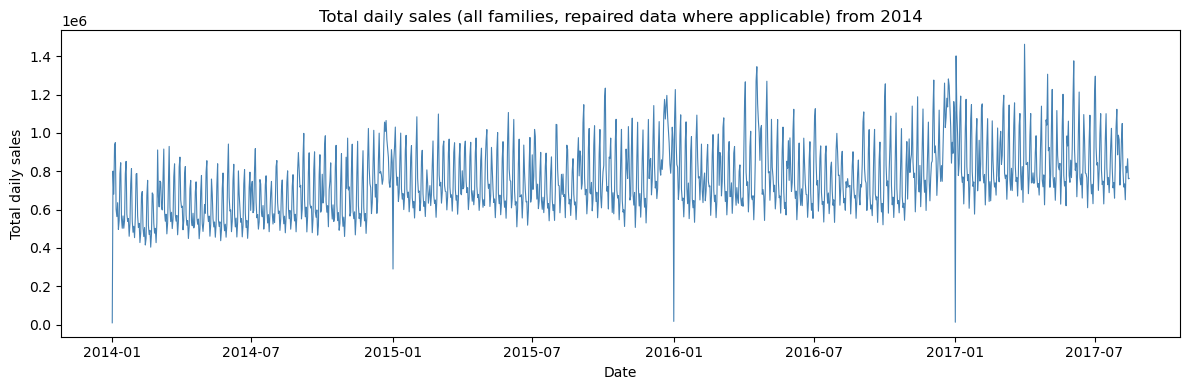

In [135]:
# Total daily sales from 2014: repaired families from repaired_df, others from train.
# Total sales (sum across all product families) from 2014 using repaired data
# Repair families: use repaired_df; other families: use original daily sales from train
daily_all_families = train.groupby(["date", "family"])["sales"].sum().unstack(fill_value=0)
for fam in families_in_repair:
    if fam in repaired_df.columns and fam in daily_all_families.columns:
        daily_all_families[fam] = repaired_df[fam].reindex(daily_all_families.index).fillna(daily_all_families[fam])
total_repaired = daily_all_families.sum(axis=1)
# Exclude January 1 of each year from train/test and all subsequent forecasting
total_repaired = total_repaired[~((total_repaired.index.month == 1) & (total_repaired.index.day == 1))]
total_from_2014 = total_repaired[total_repaired.index >= "2014-01-01"]
total_repaired.to_csv(f"{DATA}/Total_Repaired_Daily.csv")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(total_from_2014.index, total_from_2014.values, color="steelblue", linewidth=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Total daily sales")
ax.set_title("Total daily sales (all families, repaired data where applicable) from 2014")
plt.tight_layout()
plt.show()

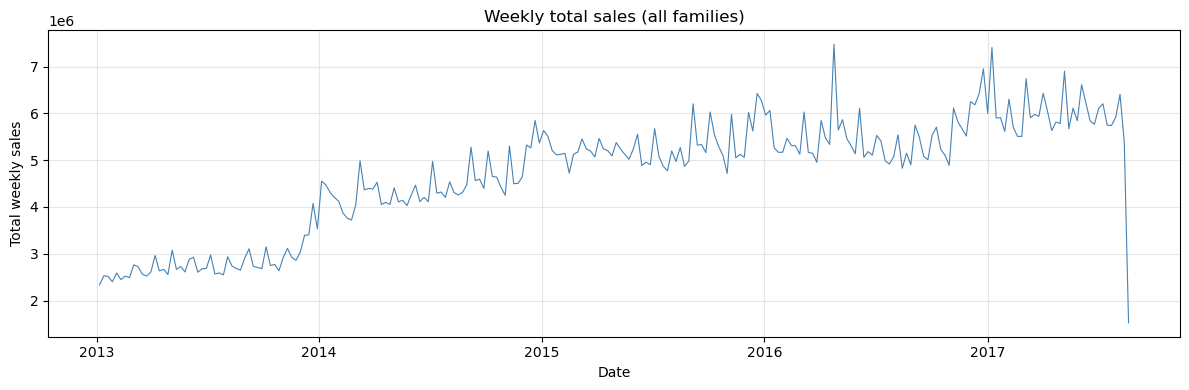

In [136]:
# Weekly total sales (resample total_repaired to weekly).
# Weekly total sales (sum across all product families)
weekly_total = total_repaired.resample("W").sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly_total.index, weekly_total.values, color="steelblue", linewidth=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Total weekly sales")
ax.set_title("Weekly total sales (all families)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

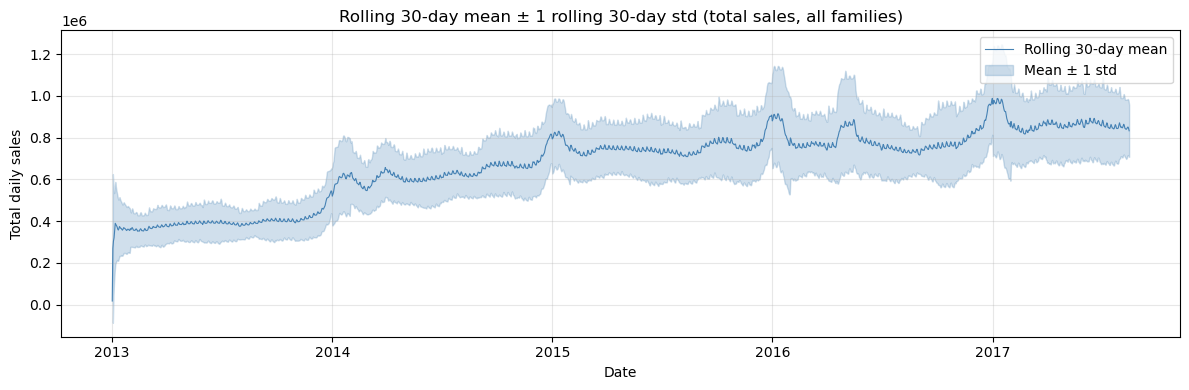

In [137]:
# Rolling 30-day mean and ±1 std for total sales (all families).
# Rolling 30-day mean and standard deviation for total sales (all product families)
rolling_mean = total_repaired.rolling(30, min_periods=1).mean()
rolling_std = total_repaired.rolling(30, min_periods=1).std()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(total_repaired.index, rolling_mean.values, color="steelblue", linewidth=0.8, label="Rolling 30-day mean")
upper = rolling_mean + rolling_std
lower = rolling_mean - rolling_std
ax.fill_between(total_repaired.index, lower.values, upper.values, color="steelblue", alpha=0.25, label="Mean ± 1 std")
ax.set_ylabel("Total daily sales")
ax.set_xlabel("Date")
ax.set_title("Rolling 30-day mean ± 1 rolling 30-day std (total sales, all families)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [138]:
# Daily forecast: ETS, ARIMA, Prophet; 80% train, 20% test; MAE, RMSE, MAPE.
# Repaired Data (total daily sales, all families): exclude 2013, 80% train / 20% test. Daily forecast 30 days ahead.
# Methods: ETS, ARIMA, Prophet. Evaluation: MAE, RMSE, MAPE.
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Repaired Data = total_repaired (sum across all product families), exclude 2013
repaired_daily = total_repaired[total_repaired.index >= "2014-01-01"].sort_index()
n = len(repaired_daily)
train_size = int(0.8 * n)
train_daily = repaired_daily.iloc[:train_size]
test_daily = repaired_daily.iloc[train_size:]
horizon_daily = 30
actual_30 = test_daily.iloc[:horizon_daily].values

def mape(actual, pred):
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

# ETS
from statsmodels.tsa.holtwinters import ExponentialSmoothing
ets = ExponentialSmoothing(train_daily.values, seasonal_periods=7, trend="add", seasonal="add")
ets_fit = ets.fit()
ets_forecast = ets_fit.forecast(horizon_daily)

# ARIMA
from statsmodels.tsa.arima.model import ARIMA
arima = ARIMA(train_daily.values, order=(2, 1, 2))
arima_fit = arima.fit()
arima_forecast = arima_fit.forecast(horizon_daily)

# Prophet
from prophet import Prophet
train_prophet = pd.DataFrame({"ds": train_daily.index, "y": train_daily.values})
prophet_m = Prophet(yearly_seasonality=True, weekly_seasonality=True)
prophet_m.fit(train_prophet)
future_daily = prophet_m.make_future_dataframe(periods=horizon_daily)
prophet_forecast = prophet_m.predict(future_daily)["yhat"].tail(horizon_daily).values

# Metrics (daily, 30-day horizon): MAE and RMSE rounded to nearest whole number, MAPE as percent
results_daily = []
for name, pred in [("ETS", ets_forecast), ("ARIMA", arima_forecast), ("Prophet", prophet_forecast)]:
    results_daily.append({
        "Method": name,
        "MAE": round(mean_absolute_error(actual_30, pred), 0),
        "RMSE": round(np.sqrt(mean_squared_error(actual_30, pred)), 0),
        "MAPE (%)": round(mape(actual_30, pred), 2),
    })
print("Daily sales forecast (30 days ahead) - Repaired Data, train 80%, test 20%:")
pd.DataFrame(results_daily)

c:\Users\cbailey\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
17:49:09 - cmdstanpy - INFO - Chain [1] start processing
17:49:09 - cmdstanpy - INFO - Chain [1] done processing


Daily sales forecast (30 days ahead) - Repaired Data, train 80%, test 20%:


,Method,MAE,RMSE,MAPE (%)
0,ETS,145830.0,206905.0,14.33
1,ARIMA,186206.0,238765.0,18.25
2,Prophet,102362.0,140412.0,10.24


In [139]:
# Weekly forecast: 4-week horizon; ETS, ARIMA, Prophet; same split and metrics.
# Weekly sales forecast (total sales, all families): one month ahead (4 weeks). ETS, ARIMA, Prophet. Same 80% train, 20% test.
repaired_weekly = repaired_daily.resample("W").sum()
nw = len(repaired_weekly)
train_size_w = int(0.8 * nw)
train_weekly = repaired_weekly.iloc[:train_size_w]
test_weekly = repaired_weekly.iloc[train_size_w:]
horizon_weekly = 4  # one month
actual_4w = test_weekly.iloc[:horizon_weekly].values

# ETS (weekly; seasonal_periods=12 for ~monthly seasonality)
ets_w = ExponentialSmoothing(train_weekly.values, seasonal_periods=12, trend="add", seasonal="add")
ets_w_fit = ets_w.fit()
ets_w_forecast = ets_w_fit.forecast(horizon_weekly)

# ARIMA (weekly)
arima_w = ARIMA(train_weekly.values, order=(2, 1, 2))
arima_w_fit = arima_w.fit()
arima_w_forecast = arima_w_fit.forecast(horizon_weekly)

# Prophet (weekly)
train_prophet_w = pd.DataFrame({"ds": train_weekly.index, "y": train_weekly.values})
prophet_w = Prophet(yearly_seasonality=True, weekly_seasonality=True)
prophet_w.fit(train_prophet_w)
future_weekly = pd.DataFrame({"ds": test_weekly.index[:horizon_weekly]})
prophet_w_forecast = prophet_w.predict(future_weekly)["yhat"].values

# Metrics (weekly, 4-week horizon): MAE and RMSE rounded to nearest whole number, MAPE as percent
results_weekly = []
for name, pred in [("ETS", ets_w_forecast), ("ARIMA", arima_w_forecast), ("Prophet", prophet_w_forecast)]:
    results_weekly.append({
        "Method": name,
        "MAE": round(mean_absolute_error(actual_4w, pred), 0),
        "RMSE": round(np.sqrt(mean_squared_error(actual_4w, pred)), 0),
        "MAPE (%)": round(mape(actual_4w, pred), 2),
    })
print("Weekly sales forecast (4 weeks / one month ahead) - Repaired Data, train 80%, test 20%:")
pd.DataFrame(results_weekly)

17:49:09 - cmdstanpy - INFO - Chain [1] start processing
17:49:09 - cmdstanpy - INFO - Chain [1] done processing


Weekly sales forecast (4 weeks / one month ahead) - Repaired Data, train 80%, test 20%:


,Method,MAE,RMSE,MAPE (%)
0,ETS,919090.0,962747.0,14.07
1,ARIMA,948814.0,997418.0,14.52
2,Prophet,382223.0,442021.0,5.88


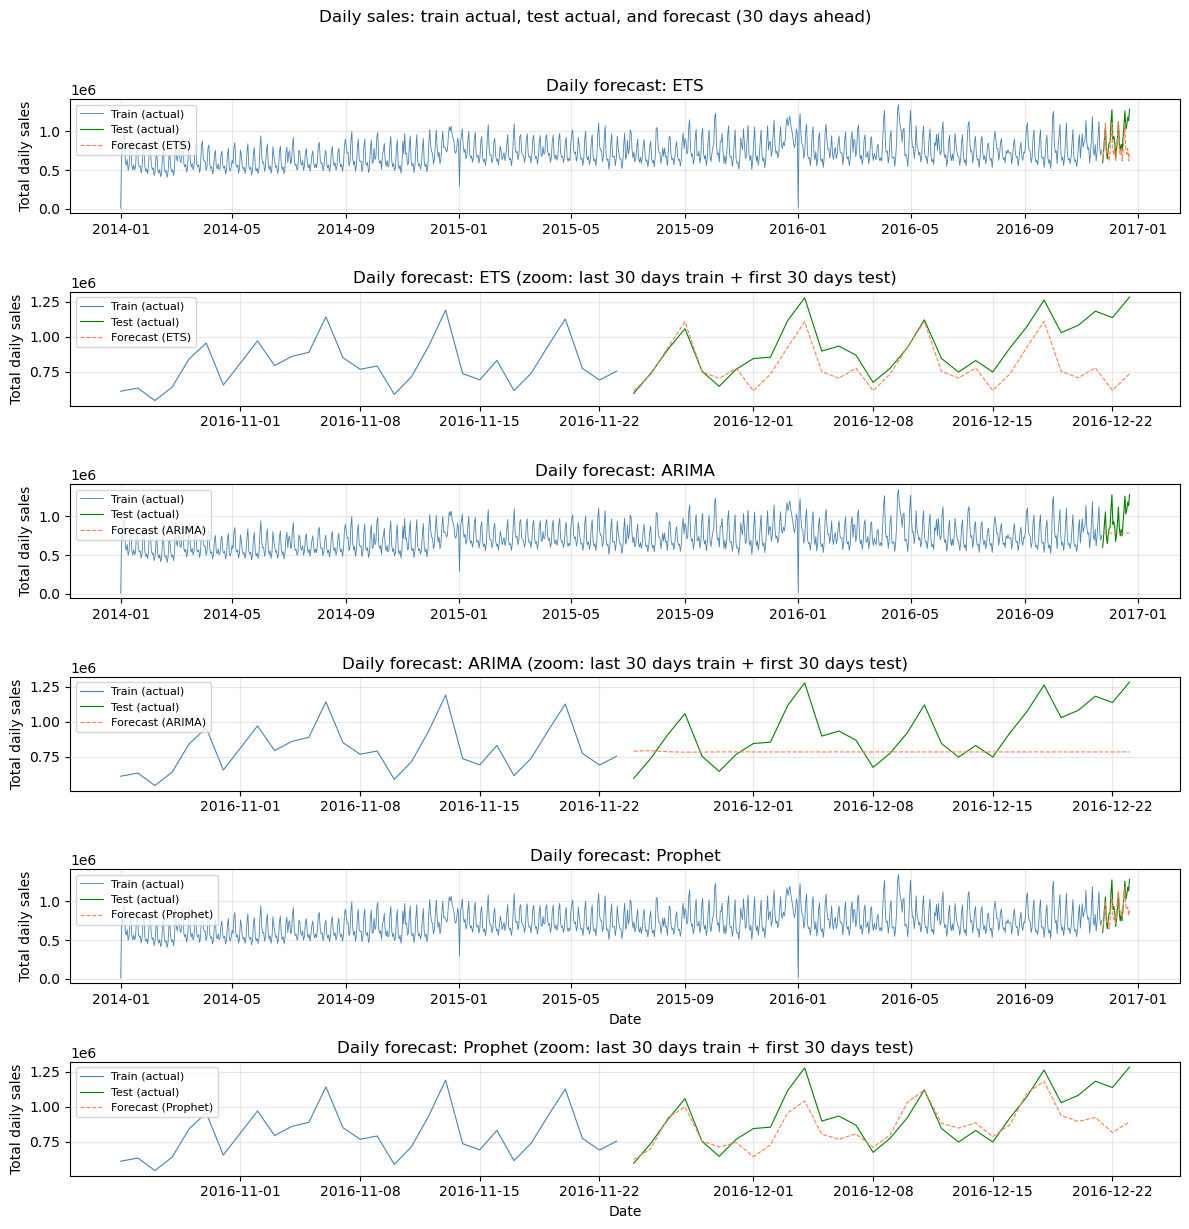

In [140]:
# Daily forecast plots: train/test actual and forecasts; zoom last 30 train + first 30 test.
# Daily forecasts: plot train actual, test actual, and each method's forecast; plus zoomed panel (last 30 days train + first 30 days test)
test_dates_30 = test_daily.index[:horizon_daily]
train_tail_30 = train_daily.tail(horizon_daily)
test_head_30 = test_daily.iloc[:horizon_daily]

fig, axes = plt.subplots(6, 1, figsize=(12, 12), sharex=False)
methods = [("ETS", ets_forecast), ("ARIMA", arima_forecast), ("Prophet", prophet_forecast)]
for i, (name, pred) in enumerate(methods):
    ax_full = axes[2 * i]
    ax_zoom = axes[2 * i + 1]
    # Full view
    ax_full.plot(train_daily.index, train_daily.values, color="steelblue", linewidth=0.6, label="Train (actual)")
    ax_full.plot(test_dates_30, test_head_30.values, color="green", linewidth=0.8, label="Test (actual)")
    ax_full.plot(test_dates_30, pred, color="coral", linewidth=0.8, linestyle="--", label=f"Forecast ({name})")
    ax_full.set_ylabel("Total daily sales")
    ax_full.set_title(f"Daily forecast: {name}")
    ax_full.legend(loc="upper left", fontsize=8)
    ax_full.grid(True, alpha=0.3)
    # Zoomed: last 30 days train + first 30 days test and forecast
    ax_zoom.plot(train_tail_30.index, train_tail_30.values, color="steelblue", linewidth=0.8, label="Train (actual)")
    ax_zoom.plot(test_dates_30, test_head_30.values, color="green", linewidth=0.8, label="Test (actual)")
    ax_zoom.plot(test_dates_30, pred, color="coral", linewidth=0.8, linestyle="--", label=f"Forecast ({name})")
    ax_zoom.set_ylabel("Total daily sales")
    ax_zoom.set_title(f"Daily forecast: {name} (zoom: last 30 days train + first 30 days test)")
    ax_zoom.legend(loc="upper left", fontsize=8)
    ax_zoom.grid(True, alpha=0.3)
axes[-1].set_xlabel("Date")
axes[-2].set_xlabel("Date")
plt.suptitle("Daily sales: train actual, test actual, and forecast (30 days ahead)", y=1.02)
plt.tight_layout()
plt.show()

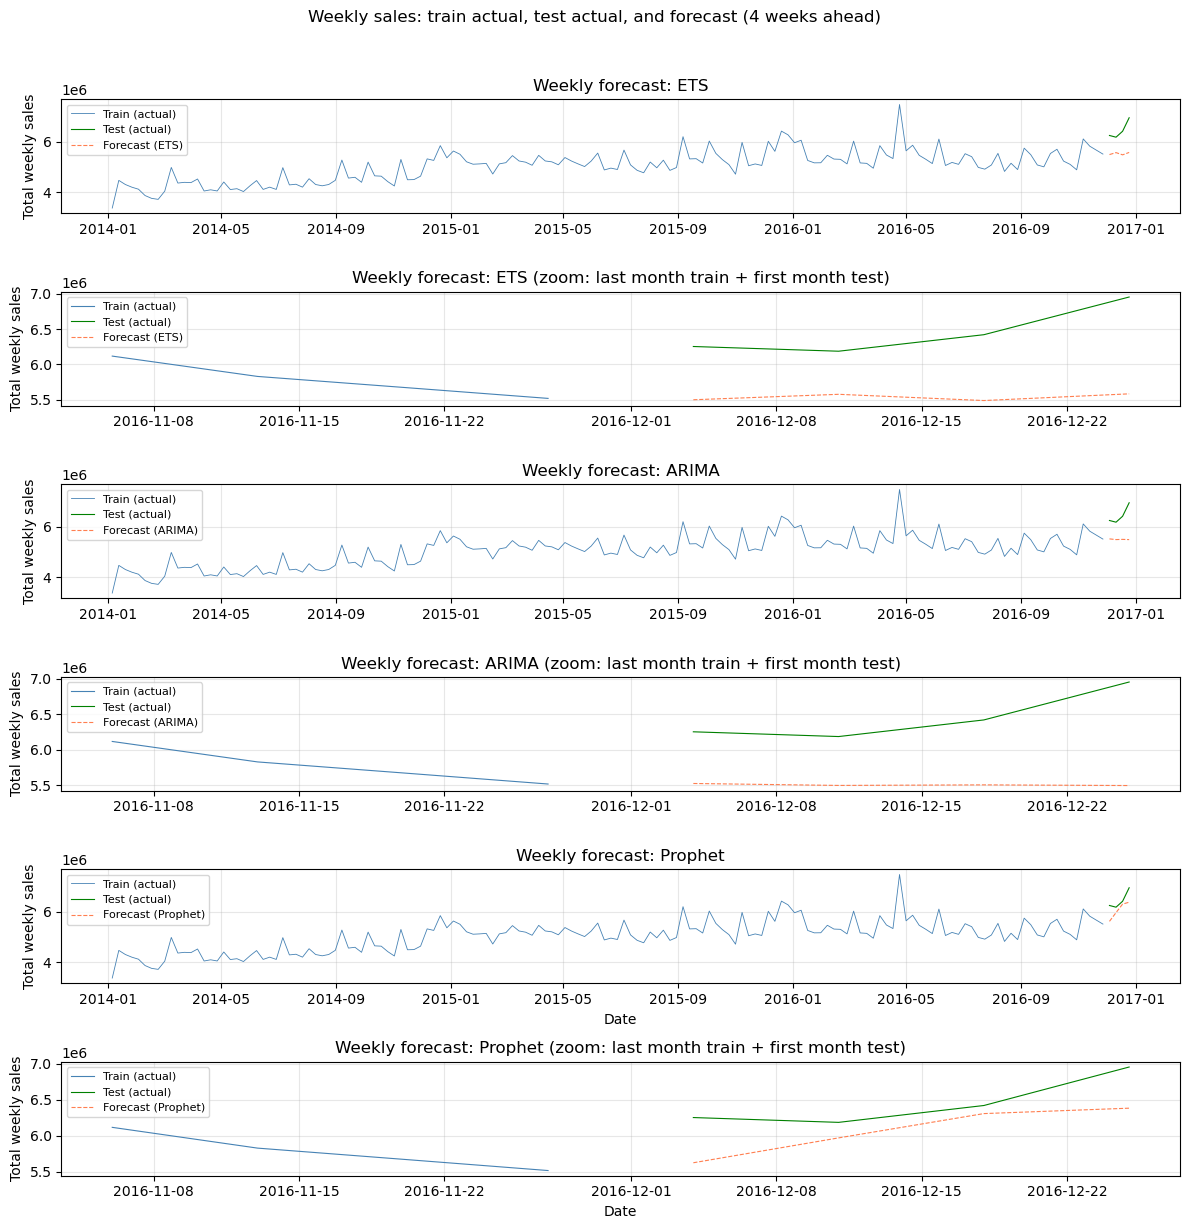

In [141]:
# Weekly forecast plots: train/test actual and forecasts; zoom last/first month.
# Weekly forecasts: plot train actual, test actual, and each method's forecast; plus zoomed panel (last month train + first month test)
test_dates_4w = test_weekly.index[:horizon_weekly]
train_tail_4w = train_weekly.tail(horizon_weekly)
test_head_4w = test_weekly.iloc[:horizon_weekly]

fig, axes = plt.subplots(6, 1, figsize=(12, 12), sharex=False)
methods_w = [("ETS", ets_w_forecast), ("ARIMA", arima_w_forecast), ("Prophet", prophet_w_forecast)]
for i, (name, pred) in enumerate(methods_w):
    ax_full = axes[2 * i]
    ax_zoom = axes[2 * i + 1]
    # Full view
    ax_full.plot(train_weekly.index, train_weekly.values, color="steelblue", linewidth=0.6, label="Train (actual)")
    ax_full.plot(test_dates_4w, test_head_4w.values, color="green", linewidth=0.8, label="Test (actual)")
    ax_full.plot(test_dates_4w, pred, color="coral", linewidth=0.8, linestyle="--", label=f"Forecast ({name})")
    ax_full.set_ylabel("Total weekly sales")
    ax_full.set_title(f"Weekly forecast: {name}")
    ax_full.legend(loc="upper left", fontsize=8)
    ax_full.grid(True, alpha=0.3)
    # Zoomed: last 4 weeks (1 month) train + first 4 weeks test and forecast
    ax_zoom.plot(train_tail_4w.index, train_tail_4w.values, color="steelblue", linewidth=0.8, label="Train (actual)")
    ax_zoom.plot(test_dates_4w, test_head_4w.values, color="green", linewidth=0.8, label="Test (actual)")
    ax_zoom.plot(test_dates_4w, pred, color="coral", linewidth=0.8, linestyle="--", label=f"Forecast ({name})")
    ax_zoom.set_ylabel("Total weekly sales")
    ax_zoom.set_title(f"Weekly forecast: {name} (zoom: last month train + first month test)")
    ax_zoom.legend(loc="upper left", fontsize=8)
    ax_zoom.grid(True, alpha=0.3)
axes[-1].set_xlabel("Date")
axes[-2].set_xlabel("Date")
plt.suptitle("Weekly sales: train actual, test actual, and forecast (4 weeks ahead)", y=1.02)
plt.tight_layout()
plt.show()

In [142]:
# Proof: total_repaired sums over all product families (repaired where applicable).
# Proof: daily sales in subsequent cells sum across ALL product families
# (Run the "Total sales from 2014" cell first so daily_all_families and total_repaired exist.)

sum_all_families = daily_all_families.sum(axis=1)
aligned = sum_all_families.reindex(total_repaired.index).fillna(0)
match = (total_repaired - aligned).abs().max() < 1e-6
assert match, "total_repaired should equal sum of daily_all_families"

print("Proof that total_repaired sums across ALL product families:")
print(f"  Number of product families in daily_all_families: {len(daily_all_families.columns)}")
print(f"  Number of repair-only families (families_in_repair): {len(families_in_repair)}")
print(f"  total_repaired equals sum over all families: {match}")
print(f"  total_repaired date range: {total_repaired.index.min().date()} to {total_repaired.index.max().date()}")
print(f"  Sample (first date) total_repaired: {total_repaired.iloc[0]:.0f}  |  sum(daily_all_families): {aligned.iloc[0]:.0f}")
pd.DataFrame({
    "Check": [
        "total_repaired = sum over all product families (repaired data where applicable)",
        "Subsequent cells (weekly, rolling, forecasts, box plots) use total_repaired",
    ],
    "Status": ["Verified", "Correct"],
})

Proof that total_repaired sums across ALL product families:
  Number of product families in daily_all_families: 33
  Number of repair-only families (families_in_repair): 7
  total_repaired equals sum over all families: True
  total_repaired date range: 2013-01-01 to 2017-08-15
  Sample (first date) total_repaired: 17851  |  sum(daily_all_families): 17851


,Check,Status
0,total_repaired = sum over all product families...,Verified
1,"Subsequent cells (weekly, rolling, forecasts, ...",Correct
